<a href="https://colab.research.google.com/github/def-himani/NYU/blob/main/qmf/AAPL_Volatility_Trading.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install arch

In [39]:
# =============================================================================
# Trading Opportunities from IV vs HV Divergence
# AAPL Options Analysis
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
from arch import arch_model
from datetime import datetime, timedelta

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f9f9f9",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

In [40]:
# ── Hongyi's IV data ─────────────────────────────────────────────

df_iv = pd.read_csv("/content/aapl_iv_output - Sheet1.csv")
df_clean = df_iv[df_iv["IV_calc"].notna()].copy()
df_clean = df_clean[df_clean["IV_calc"] > 0].copy()
valuation_date = datetime(2026, 5, 3)
# Spot price
S = 280.14  # Spot price as of May 3 snapshot
print(f"Spot price: ${S:.2f}")

# Expiry
expiry = datetime(2026, 5, 29)
T = 0.0767
print(f"Days to expiry: {(expiry - valuation_date).days}  |  T = {T:.4f} yrs")
print(f"\nValid IV rows: {len(df_clean)}")
print(df_clean[["strike","mid_price","IV_calc","impliedVolatility"]].to_string(index=False))

Spot price: $280.14
Days to expiry: 26  |  T = 0.0767 yrs

Valid IV rows: 26
 strike  mid_price  IV_calc  impliedVolatility
    245     35.950 0.235836           0.436407
    250     31.200 0.250110           0.392096
    255     26.700 0.263289           0.338386
    260     22.075 0.247517           0.303352
    265     17.750 0.238394           0.277961
    270     13.825 0.233067           0.262336
    275     10.300 0.226633           0.251900
    280      7.350 0.222377           0.240974
    285      5.000 0.219233           0.235725
    290      3.275 0.218385           0.232735
    295      2.070 0.218829           0.232796
    300      1.275 0.220529           0.232185
    305      0.775 0.223453           0.235115
    310      0.485 0.228968           0.240242
    315      0.300 0.234142           0.245369
    320      0.190 0.240319           0.252449
    325      0.135 0.250431           0.265144
    330      0.090 0.257545           0.269539
    335      0.060 0.264226   

In [41]:
# ── Pippa's HV data (EWMA + GARCH) ─────────────────────────────

hv_df = pd.read_csv("/content/aapl_historical_volatility.csv", index_col=0, parse_dates=True)

# Without Rolling
hv_df = hv_df.drop(columns=[c for c in hv_df.columns if "Rolling" in c], errors="ignore")

hv_latest = hv_df.iloc[-1]

print("── Latest Historical Volatility ──")
for col in hv_df.columns:
    print(f"  {col}: {hv_latest[col]:.2%}")

── Latest Historical Volatility ──
  EWMA: 25.24%
  GARCH(1,1): 23.00%


In [42]:
# ── ATM IV + Volatility Risk Premium ──────────────────────────────────

df_clean["moneyness"] = abs(df_clean["strike"] - S)
atm_row    = df_clean.loc[df_clean["moneyness"].idxmin()]
atm_strike = atm_row["strike"]
atm_iv     = atm_row["IV_calc"]
atm_iv_yf  = atm_row["impliedVolatility"]

print(f"ATM Strike:         ${atm_strike:.0f}")
print(f"ATM IV (BS calc):   {atm_iv:.2%}")
print(f"ATM IV (yfinance):  {atm_iv_yf:.2%}")

print("\n── Volatility Risk Premium (VRP = ATM IV − HV) ──")
vrp = {}
for col in hv_df.columns:
    vrp[col] = atm_iv - hv_latest[col]
    direction = "EXPENSIVE → sell vol" if vrp[col] > 0 else "CHEAP → buy vol"
    print(f"  IV − {col}: {vrp[col]:+.2%}  ({direction})")

ATM Strike:         $280
ATM IV (BS calc):   22.24%
ATM IV (yfinance):  24.10%

── Volatility Risk Premium (VRP = ATM IV − HV) ──
  IV − EWMA: -3.00%  (CHEAP → buy vol)
  IV − GARCH(1,1): -0.77%  (CHEAP → buy vol)


In [43]:
# ── Summary Table ─────────────────────────────────────────────────────

summary = pd.DataFrame({
    "Metric": [
        "Spot Price (S)",
        "ATM Strike",
        "ATM IV — BS Calculated",
        "ATM IV — yfinance",
        "HV — EWMA (λ=0.94)",
        "HV — GARCH(1,1)",
        "VRP (IV − EWMA HV)",
        "VRP (IV − GARCH HV)",
    ],
    "Value": [
        f"${S:.2f}",
        f"${atm_strike:.0f}",
        f"{atm_iv:.2%}",
        f"{atm_iv_yf:.2%}",
        f"{hv_latest['EWMA']:.2%}",
        f"{hv_latest['GARCH(1,1)']:.2%}",
        f"{vrp['EWMA']:+.2%}",
        f"{vrp['GARCH(1,1)']:+.2%}",
    ]
})

print(summary.to_string(index=False))

                Metric   Value
        Spot Price (S) $280.14
            ATM Strike    $280
ATM IV — BS Calculated  22.24%
     ATM IV — yfinance  24.10%
    HV — EWMA (λ=0.94)  25.24%
       HV — GARCH(1,1)  23.00%
    VRP (IV − EWMA HV)  -3.00%
   VRP (IV − GARCH HV)  -0.77%


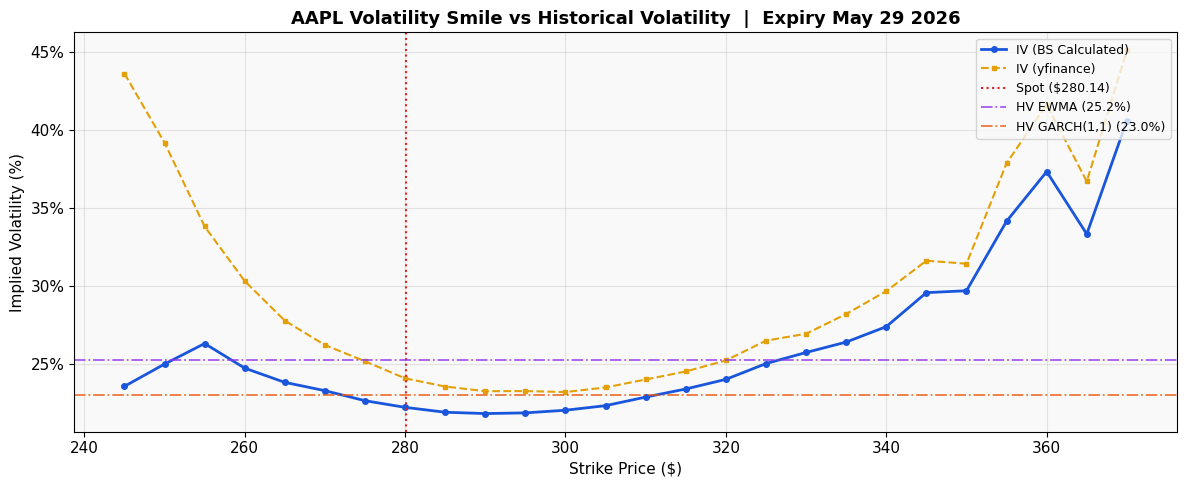

In [44]:
# ── Chart 1 — Volatility Smile ───────────────────────────────────────

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df_clean["strike"], df_clean["IV_calc"] * 100,
        color="#1a56db", lw=2, marker="o", ms=4, label="IV (BS Calculated)")
ax.plot(df_clean["strike"], df_clean["impliedVolatility"] * 100,
        color="#e3a008", lw=1.5, ls="--", marker="s", ms=3, label="IV (yfinance)")

ax.axvline(S, color="#e02424", ls=":", lw=1.5, label=f"Spot (${S:.2f})")

hv_colors = {"EWMA": "#9333ea", "GARCH(1,1)": "#ea580c"}
for col, c in hv_colors.items():
    ax.axhline(hv_latest[col] * 100, color=c, ls="-.", lw=1.3, alpha=0.8,
               label=f"HV {col} ({hv_latest[col]:.1%})")

ax.set_title("AAPL Volatility Smile vs Historical Volatility  |  Expiry May 29 2026",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Strike Price ($)")
ax.set_ylabel("Implied Volatility (%)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

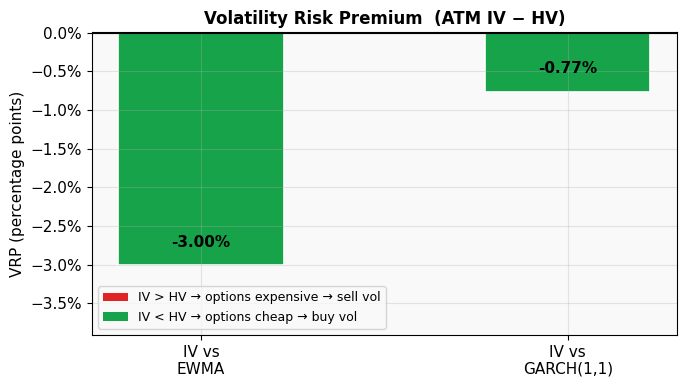

In [45]:
# ── Chart 2 — VRP Bar Chart ──────────────────────────────────────────

fig, ax = plt.subplots(figsize=(7, 4))

labels = ["IV vs\nEWMA", "IV vs\nGARCH(1,1)"]
values = [vrp["EWMA"]*100, vrp["GARCH(1,1)"]*100]

colors = ["#e02424" if v > 0 else "#16a34a" for v in values]

bars = ax.bar(labels, values, color=colors, width=0.45, edgecolor="white", lw=1.2)
ax.axhline(0, color="black", lw=0.8)

for bar, val in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + (0.2 if val < 0 else -0.2),   # ensures visibility for negative bars
        f"{val:+.2f}%",
        ha="center",
        va="bottom" if val < 0 else "top",
        fontsize=11,
        fontweight="bold",
        color="black"
    )

ax.set_title("Volatility Risk Premium  (ATM IV − HV)", fontsize=12, fontweight="bold")
ax.set_ylabel("VRP (percentage points)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))

ax.set_ylim(min(values) * 1.3, max(values) * 1.3 + 1)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor="#e02424", label="IV > HV → options expensive → sell vol"),
    Patch(facecolor="#16a34a", label="IV < HV → options cheap → buy vol"),
], fontsize=9)

plt.tight_layout()
plt.show()

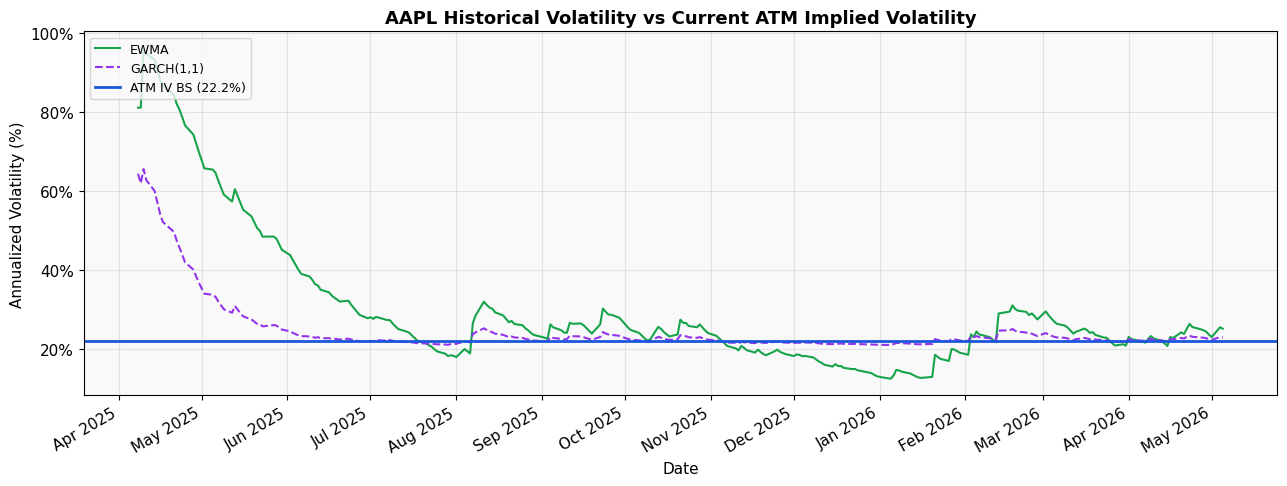

In [46]:
# ── Chart 3 — HV Time Series + ATM IV reference line ─────────────────

fig, ax = plt.subplots(figsize=(13, 5))

styles = ["-", "--", "-."]
colors = ["#16a34a", "#9333ea", "#ea580c"]
for i, col in enumerate(hv_df.columns):
    ax.plot(hv_df.index, hv_df[col]*100, label=col, lw=1.5,
            ls=styles[i], color=colors[i])

ax.axhline(atm_iv*100,    color="#1a56db", lw=2,   ls="-",  label=f"ATM IV BS ({atm_iv:.1%})")

ax.set_title("AAPL Historical Volatility vs Current ATM Implied Volatility", fontsize=13, fontweight="bold")
ax.set_ylabel("Annualized Volatility (%)")
ax.set_xlabel("Date")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.autofmt_xdate()
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

In [47]:
# ──  Trade Proposal + Breakevens (LONG STRADDLE) ──────────────────────
# IV < HV → options are cheap → buy volatility → long straddle
# Using put-call parity to estimate ATM put: P = C - S + K * e^(-rT)

r = 0.0372
S = 280.14
T = 0.0767

atm_call_mid   = atm_row["mid_price"]
atm_put_approx = atm_call_mid - S + atm_strike * np.exp(-r * T)
total_cost     = atm_call_mid + atm_put_approx
be_upper       = atm_strike + total_cost
be_lower       = atm_strike - total_cost

print("── Long ATM Straddle Trade Proposal ──")
print(f"  Strategy:               Buy ATM Call + Buy ATM Put")
print(f"  Strike:                 ${atm_strike:.0f}")
print(f"  Expiry:                 May 29, 2026")
print(f"  Call mid price:         ${atm_call_mid:.2f}")
print(f"  Put price (put-call):   ${atm_put_approx:.2f}")
print(f"  Total cost:             ${total_cost:.2f}")
print(f"  Max loss:               ${total_cost:.2f}  (AAPL stays exactly at ${atm_strike:.0f})")
print(f"  Upper breakeven:        ${be_upper:.2f}")
print(f"  Lower breakeven:        ${be_lower:.2f}")
print(f"  Profit zone:            below ${be_lower:.2f}  or  above ${be_upper:.2f}")
print()
print("  Rationale:")
print(f"  IV ({atm_iv:.1%}) < HV across EWMA/GARCH")
print(f"  → market is underpricing volatility relative to recent realized moves")
print(f"  → buying vol profits if AAPL moves more than IV implies")
print()
print("  Risk caveats:")
print("  • Max loss is capped at total premium paid — no unlimited downside")
print("  • Long gamma: needs a big move in either direction to profit")
print("  • Time decay (theta) works against you every day until expiry")
print("  • AAPL options are American-style (early exercise risk on the put)")
print("  • IV could drop further, reducing position value immediately")

── Long ATM Straddle Trade Proposal ──
  Strategy:               Buy ATM Call + Buy ATM Put
  Strike:                 $280
  Expiry:                 May 29, 2026
  Call mid price:         $7.35
  Put price (put-call):   $6.41
  Total cost:             $13.76
  Max loss:               $13.76  (AAPL stays exactly at $280)
  Upper breakeven:        $293.76
  Lower breakeven:        $266.24
  Profit zone:            below $266.24  or  above $293.76

  Rationale:
  IV (22.2%) < HV across EWMA/GARCH
  → market is underpricing volatility relative to recent realized moves
  → buying vol profits if AAPL moves more than IV implies

  Risk caveats:
  • Max loss is capped at total premium paid — no unlimited downside
  • Long gamma: needs a big move in either direction to profit
  • Time decay (theta) works against you every day until expiry
  • AAPL options are American-style (early exercise risk on the put)
  • IV could drop further, reducing position value immediately


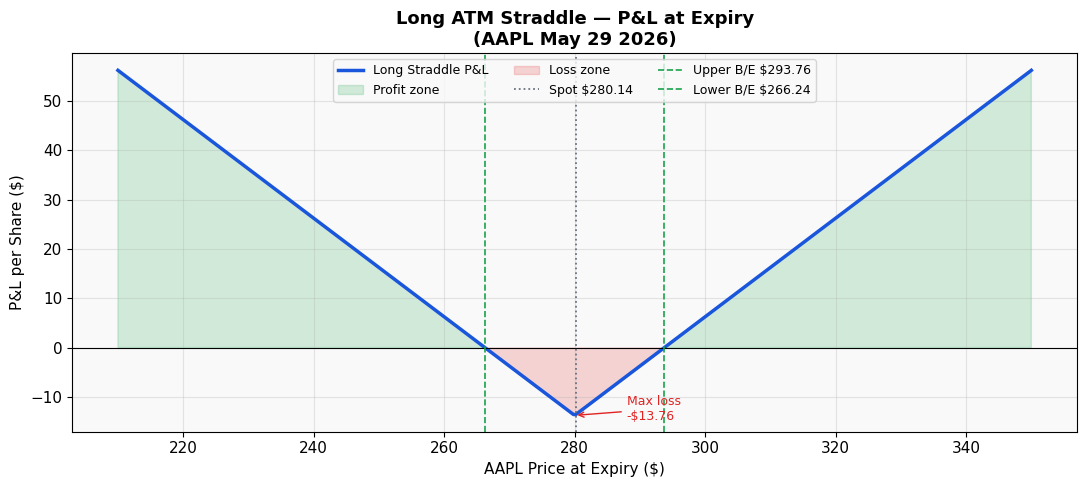

In [48]:
# ── Chart 4 — Long Straddle P&L at Expiry ───────────────────────────

stock_range = np.linspace(atm_strike * 0.75, atm_strike * 1.25, 400)

long_call_pnl = np.where(stock_range > atm_strike,
                          (stock_range - atm_strike) - atm_call_mid,
                          -atm_call_mid)
long_put_pnl  = np.where(stock_range < atm_strike,
                          (atm_strike - stock_range) - atm_put_approx,
                          -atm_put_approx)
straddle_pnl  = long_call_pnl + long_put_pnl

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(stock_range, straddle_pnl, color="#1a56db", lw=2.5, label="Long Straddle P&L")
ax.fill_between(stock_range, straddle_pnl, 0,
                where=(straddle_pnl > 0), alpha=0.18, color="#16a34a", label="Profit zone")
ax.fill_between(stock_range, straddle_pnl, 0,
                where=(straddle_pnl < 0), alpha=0.18, color="#e02424", label="Loss zone")

ax.axhline(0, color="black", lw=0.8)
ax.axvline(S,        color="#6b7280", ls=":",  lw=1.3, label=f"Spot ${S:.2f}")
ax.axvline(be_upper, color="#16a34a", ls="--", lw=1.2, label=f"Upper B/E ${be_upper:.2f}")
ax.axvline(be_lower, color="#16a34a", ls="--", lw=1.2, label=f"Lower B/E ${be_lower:.2f}")

ax.annotate(f"Max loss\n-${total_cost:.2f}",
            xy=(atm_strike, -total_cost),
            xytext=(atm_strike + 8, -total_cost - 1),
            fontsize=9, color="#e02424",
            arrowprops=dict(arrowstyle="->", color="#e02424"))

ax.set_title("Long ATM Straddle — P&L at Expiry\n(AAPL May 29 2026)", fontsize=13, fontweight="bold")
ax.set_xlabel("AAPL Price at Expiry ($)")
ax.set_ylabel("P&L per Share ($)")
ax.legend(loc="upper center", fontsize=9, ncol=3)
plt.tight_layout()
plt.show()